In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from utils.formatting import calculate_scale
from variables import period_labels, colors, company, color_ratings

In [2]:
def style_spines(ax=None, linewidth=0.75, alpha=0.5):
    if ax is None:
        ax = plt.gca()

    for spine in ax.spines.values():
        spine.set_linewidth(linewidth)
        spine.set_alpha(alpha)

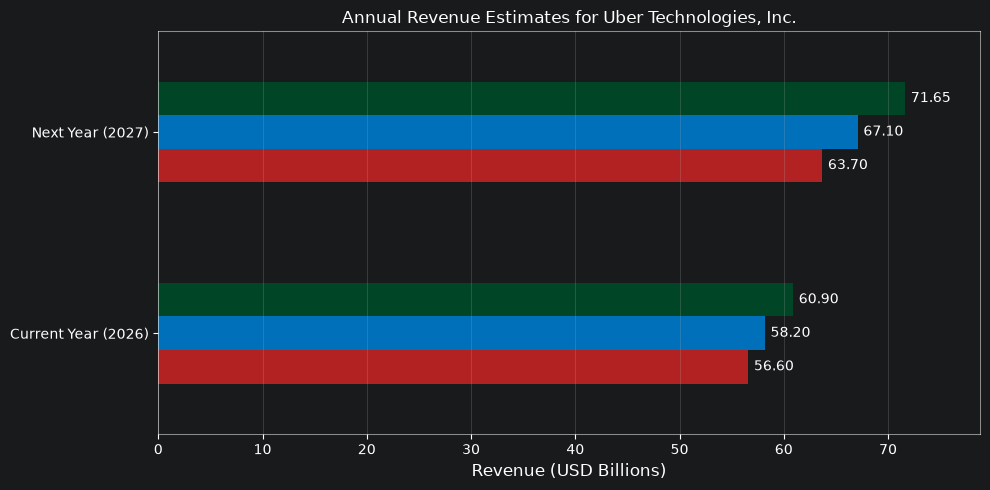

In [3]:
short_name = company.info["shortName"]
three_colors = [color for color in colors.values()]


def plot_revenue_estimates(revenue, title):
    scale, unit = calculate_scale(revenue[["low", "avg", "high"]].max().max())

    ax = (revenue.set_index("period")[["low", "avg", "high"]] / scale).plot(kind="barh", figsize=(10, 5),
                                                                            color=three_colors, legend=False)

    for container in ax.containers:
        labels = [f"{value:.2f}" for value in container.datavalues]
        ax.bar_label(container, labels=labels, padding=4)

    plt.title(f"{title} Revenue Estimates for {short_name}", fontsize=12)
    plt.xlabel(f"Revenue ({currency} {unit})", fontsize=12)
    plt.ylabel("")
    plt.yticks(rotation=0)
    plt.grid(axis="x", alpha=0.3)
    ax.margins(x=0.1)

    style_spines(ax=ax)

    plt.tight_layout()
    plt.show()


revenue = company.get_revenue_estimate().reset_index()
currency = revenue["currency"].iloc[0]

revenue["period"] = revenue["period"].map(period_labels).fillna(revenue["period"])

annual = revenue[revenue["period"].str.contains("Year")]
plot_revenue_estimates(annual, "Annual")

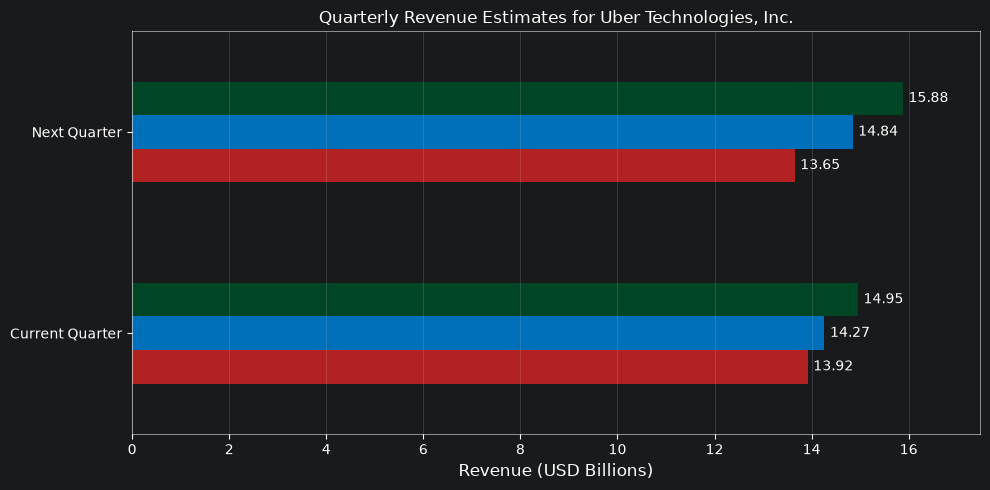

In [4]:
quarterly = revenue[revenue["period"].str.contains("Quarter")]
plot_revenue_estimates(quarterly, "Quarterly")

In [5]:
revenue = company.get_revenue_estimate().reset_index().set_index("period")
base_year = company.income_stmt.loc["Total Revenue"].iloc[0]

revenue_growth = []
for period in ["0y", "+1y"]:
    base = (base_year if period == "0y" else revenue.loc["0y", "avg"])
    estimate = revenue.loc[period]

    revenue_growth.append({
        "Year": period_labels[period],
        "Low": round((estimate["low"] / base - 1) * 100, 2),
        "Average": round((estimate["avg"] / base - 1) * 100, 2),
        "High": round((estimate["high"] / base - 1) * 100, 2)
    })

revenue_growth = pd.DataFrame(revenue_growth)

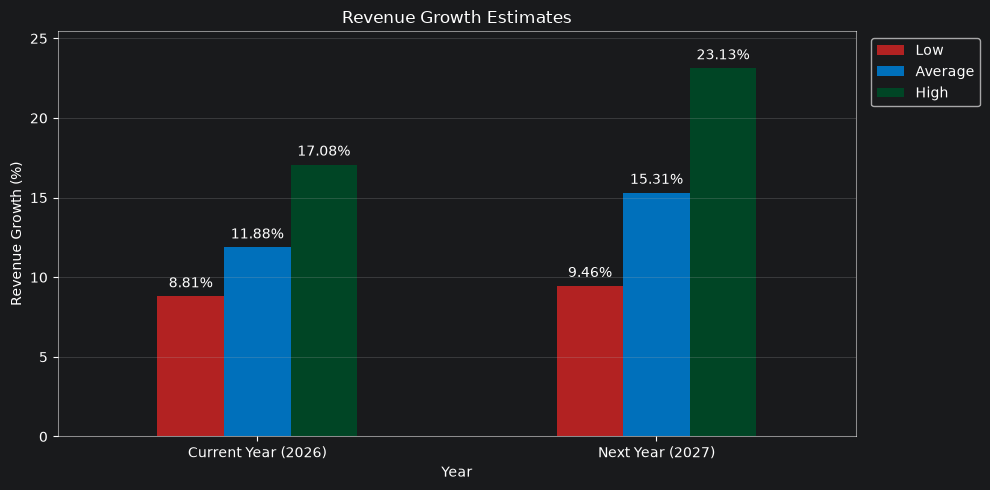

In [6]:
ax = revenue_growth.set_index("Year")[["Low", "Average", "High"]].plot(kind="bar", figsize=(10, 5), color=three_colors)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=4)

plt.ylabel("Revenue Growth (%)")
plt.title("Revenue Growth Estimates")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

ax.margins(y=0.1)

plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")

style_spines(ax=ax)

plt.tight_layout()
plt.show()

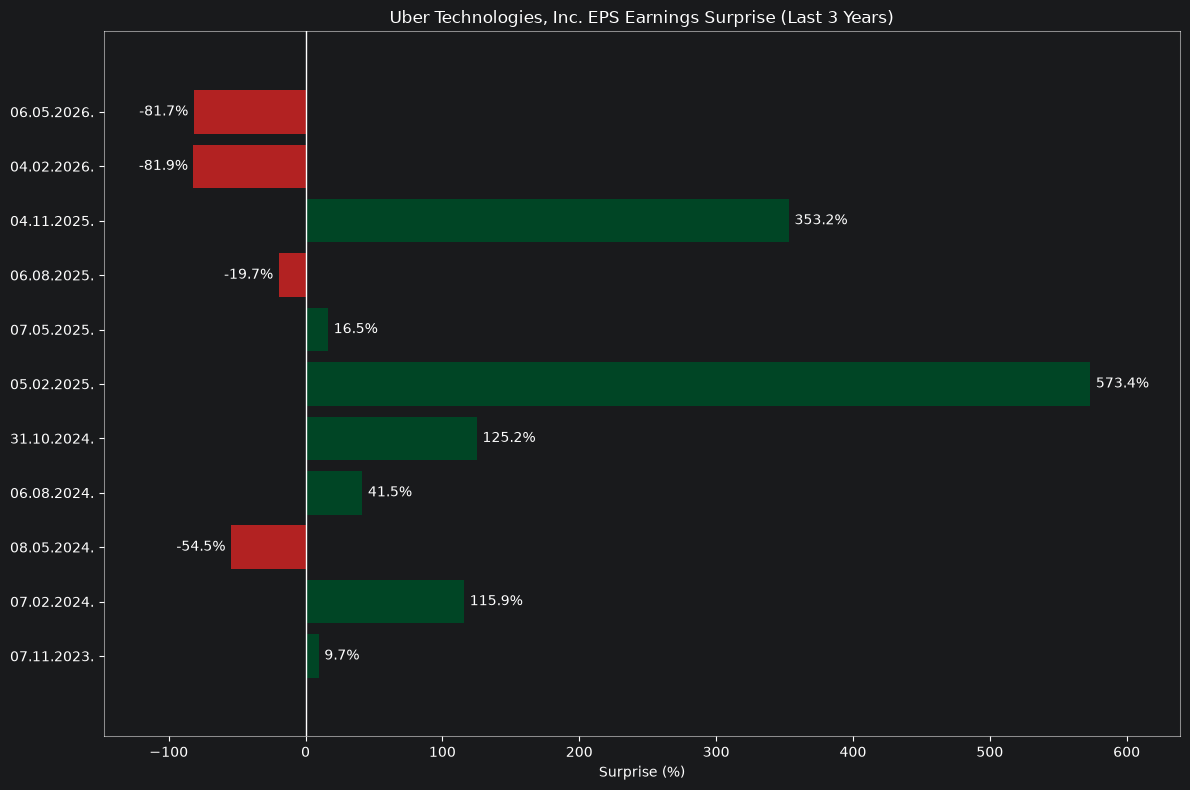

In [7]:
earnings = company.get_earnings_dates(limit=50).reset_index()
earnings = earnings.dropna(subset=["Surprise(%)"])

today = pd.Timestamp.today(tz=earnings["Earnings Date"].dt.tz).normalize()
cutoff = today - pd.DateOffset(years=3)

earnings = earnings[earnings["Earnings Date"] >= cutoff]

earnings["Date"] = earnings["Earnings Date"].dt.strftime("%d.%m.%Y.")
earnings = earnings.sort_values("Earnings Date")

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(earnings["Date"], earnings["Surprise(%)"], color=[colors["green"] if surprise >= 0 else colors["red"]
                                                                 for surprise in earnings["Surprise(%)"]])
ax.bar_label(bars, labels=[f"{value:.1f}%" for value in earnings["Surprise(%)"]], padding=4)

ax.axvline(0, color="white", lw=1)

ax.margins(x=0.1, y=0.1)

ax.set_title(f"{short_name} EPS Earnings Surprise (Last 3 Years)")
ax.set_xlabel("Surprise (%)")
ax.set_ylabel("")

style_spines(ax=ax)

plt.tight_layout()
plt.show()

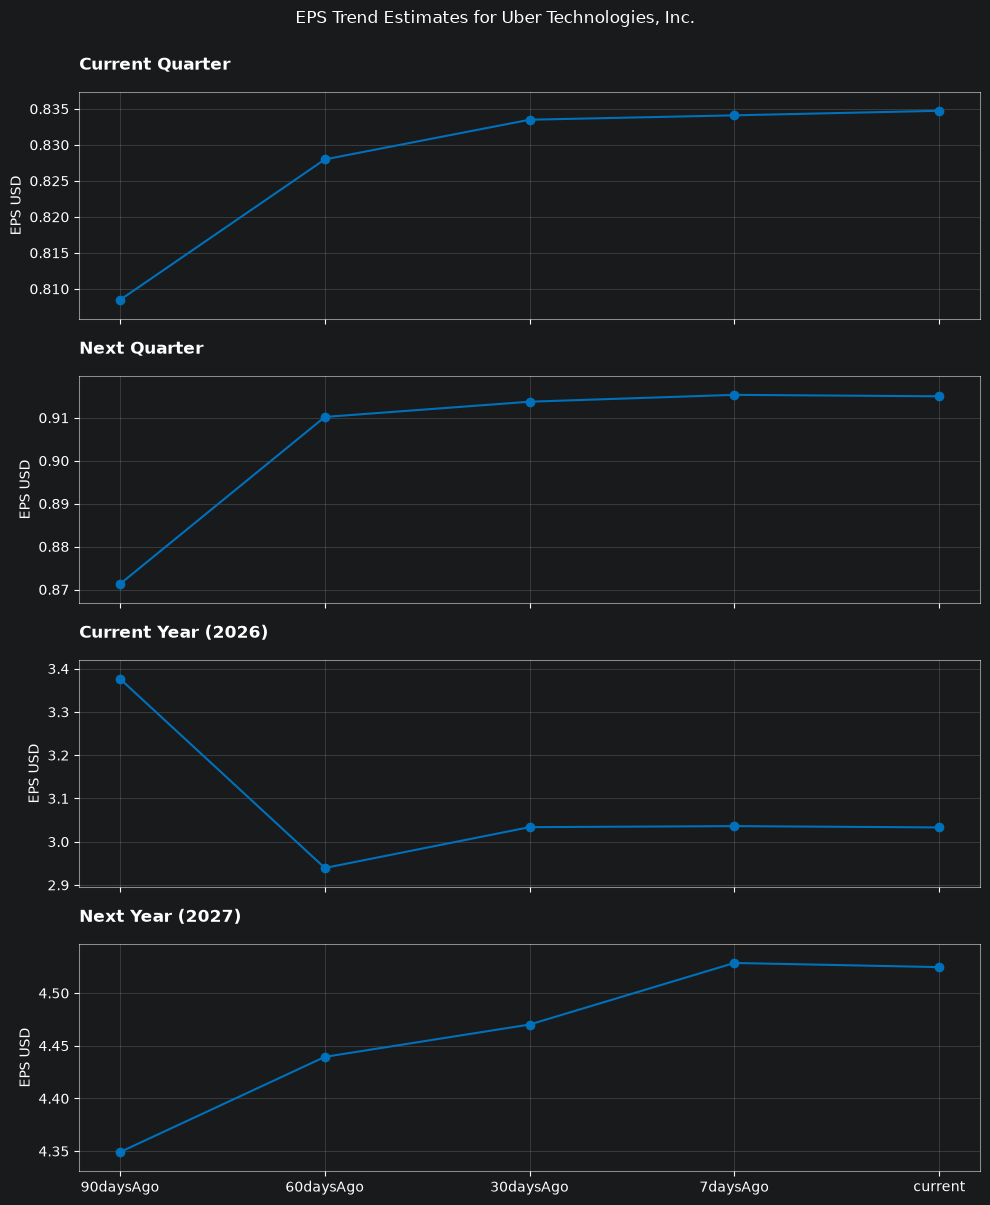

In [8]:
eps_trend = company.get_eps_trend().reset_index()
currency = eps_trend["currency"].iloc[0]

eps_trend["period"] = eps_trend["period"].map(period_labels).fillna(eps_trend["period"])
time_columns = ["90daysAgo", "60daysAgo", "30daysAgo", "7daysAgo", "current"]

fig, axes = plt.subplots(len(eps_trend), 1, figsize=(10, 3 * len(eps_trend)), sharex=True, squeeze=False)

axes = axes.flatten()

for ax, (_, row) in zip(axes, eps_trend.iterrows()):
    y = pd.to_numeric(row[time_columns], errors="coerce")

    ax.plot(time_columns, y, marker="o", color=colors["blue"])
    ax.set_title(row.get("period", "-"), fontsize=12, fontweight="bold", loc="left", pad=16)
    ax.set_ylabel(f"EPS {currency}")
    ax.grid(True, alpha=0.3)
    ax.margins(y=0.1)

    style_spines(ax=ax)

fig.suptitle(f"EPS Trend Estimates for {short_name}", fontsize=12, y=1.0)

plt.tight_layout()
plt.show()

In [9]:
pct_change = (eps_trend[time_columns].pct_change(axis=1) * 100).iloc[:, 1:].map(lambda number: f"{number:.2f}%")
pct_change = pd.concat([eps_trend["period"], pct_change], axis=1)

pct_change

,period,60daysAgo,30daysAgo,7daysAgo,current
0,Current Quarter,2.41%,0.67%,0.07%,0.08%
1,Next Quarter,4.46%,0.39%,0.18%,-0.04%
2,Current Year (2026),-12.94%,3.21%,0.08%,-0.10%
3,Next Year (2027),2.08%,0.69%,1.31%,-0.09%


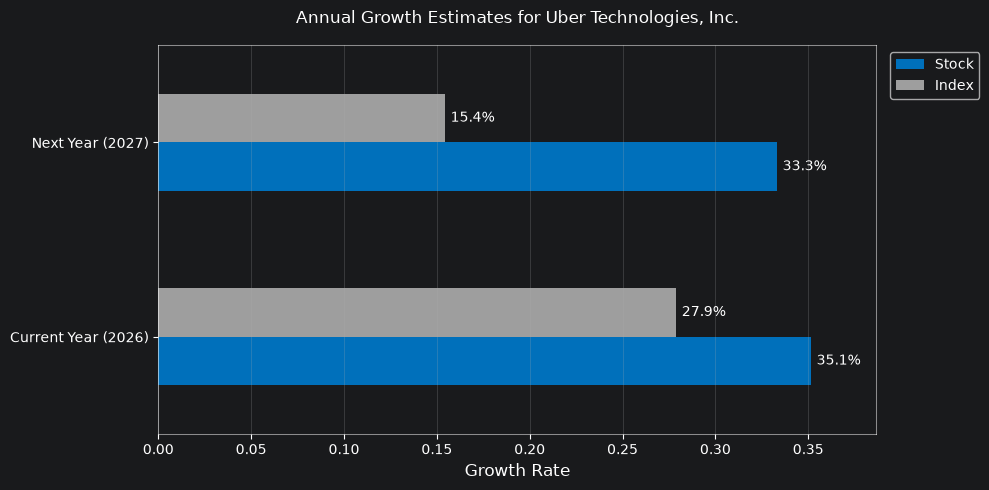

In [10]:
growth_est = company.get_growth_estimates().reset_index()
growth_est = growth_est[growth_est["period"] != "LTG"]

growth_est["period"] = growth_est["period"].map(period_labels).fillna(growth_est["period"])


def plot_growth_estimates(growth_est, title):
    ax = growth_est.set_index("period")[["stockTrend", "indexTrend"]].plot(kind="barh", figsize=(10, 5),
                                                                           color=[colors["blue"], colors["gray"]],
                                                                           legend=False)

    ax.legend(["Stock", "Index"], bbox_to_anchor=(1.01, 1), loc="upper left")

    for container in ax.containers:
        ax.bar_label(container, labels=[f"{value:.1%}" for value in container.datavalues], padding=4)

    plt.title(f"{title} Growth Estimates for {short_name}", fontsize=12, pad=16)
    plt.xlabel("Growth Rate", fontsize=12)
    plt.ylabel("")
    plt.grid(axis="x", alpha=0.3)
    ax.margins(x=0.1)

    style_spines(ax=ax)

    plt.tight_layout()
    plt.show()


annual = growth_est[growth_est["period"].str.contains("Year")]
plot_growth_estimates(annual, "Annual")

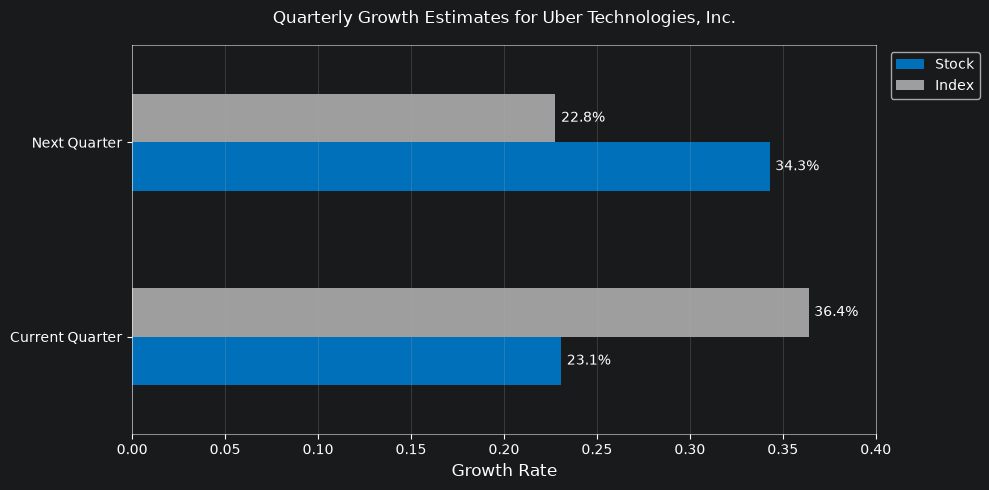

In [11]:
quarter = growth_est[growth_est["period"].str.contains("Quarter")]
plot_growth_estimates(quarter, "Quarterly")

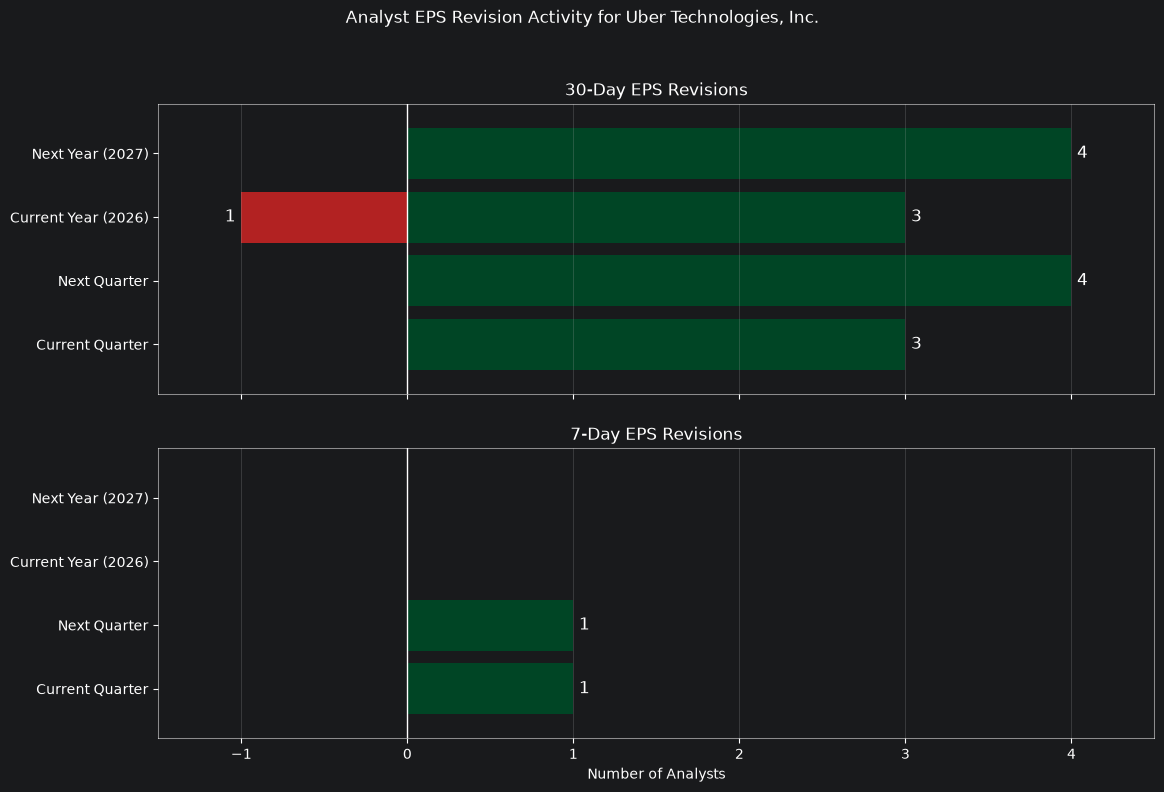

In [12]:
eps_rev = company.get_eps_revisions().reset_index()
eps_rev["period"] = eps_rev["period"].map(period_labels).fillna(eps_rev["period"])


def set_labels(series):
    return [f"{value:.0f}" if value else "" for value in series]


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

up30 = ax1.barh(eps_rev["period"], eps_rev["upLast30days"], label="Up", color=colors["green"])
down30 = ax1.barh(eps_rev["period"], -eps_rev["downLast30days"], label="Down", color=colors["red"])
ax1.axvline(0, color="white", lw=1)
ax1.set_title("30-Day EPS Revisions")

ax1.bar_label(up30, labels=set_labels(eps_rev["upLast30days"]), padding=4, fontsize=12)
ax1.bar_label(down30, labels=set_labels(eps_rev["downLast30days"]), padding=4, fontsize=12)

up7 = ax2.barh(eps_rev["period"], eps_rev["upLast7days"], color=colors["green"])
down7 = ax2.barh(eps_rev["period"], -eps_rev["downLast7Days"], color=colors["red"])
ax2.axvline(0, color="white", lw=1)
ax2.set_title("7-Day EPS Revisions")
ax2.set_xlabel("Number of Analysts")

ax2.bar_label(up7, labels=set_labels(eps_rev["upLast7days"]), padding=4, fontsize=12)
ax2.bar_label(down7, labels=set_labels(eps_rev["downLast7Days"]), padding=4, fontsize=12)

for ax in (ax1, ax2):
    ax.margins(x=0.1, y=0.1)
    ax.grid(axis="x", alpha=0.3)
    style_spines(ax=ax)

fig.suptitle(f"Analyst EPS Revision Activity for {short_name}", fontsize=12, y=1.0)

plt.tight_layout(pad=2)
plt.show()

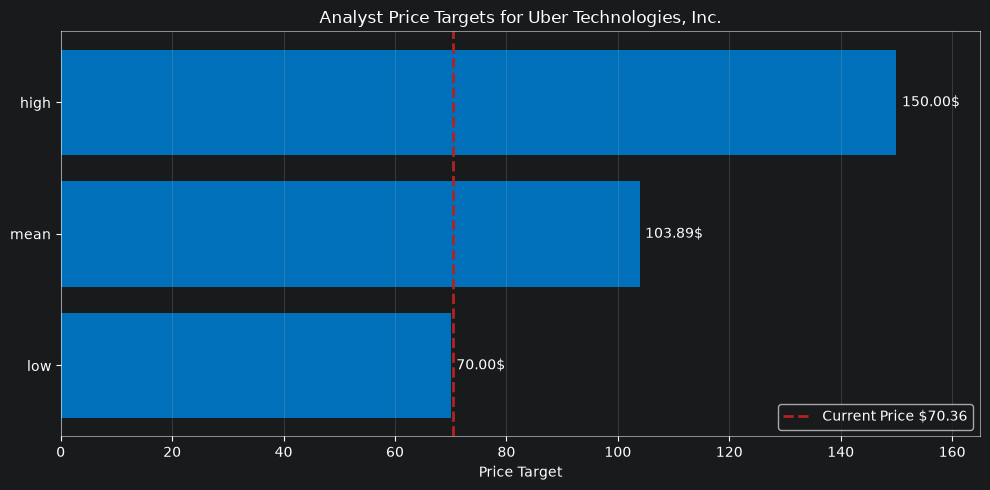

In [13]:
targets = company.get_analyst_price_targets()

targets = pd.DataFrame(list(targets.items()), columns=["Target", "Price"])
current_price = targets.loc[targets["Target"] == "current", "Price"].values[0]

targets = targets[~targets["Target"].isin(["current", "median"])]
targets = targets.sort_values("Price")

plt.figure(figsize=(10, 5))

bars = plt.barh(targets["Target"], targets["Price"], color=colors["blue"])

plt.bar_label(bars, fmt="%.2f$", padding=4)

plt.axvline(current_price, color=colors["red"], linestyle="--", linewidth=2,
            label=f"Current Price ${current_price:.2f}")

plt.xlabel("Price Target")
plt.title(f"Analyst Price Targets for {short_name}")
plt.legend()

plt.margins(x=0.1)
plt.grid(axis="x", alpha=0.3)

style_spines()

plt.tight_layout()
plt.show()

In [14]:
for label in ["low", "mean", "high"]:
    price = targets.loc[targets["Target"] == label, "Price"].values[0]
    upside = (price - current_price) / current_price * 100
    print(f"{label.capitalize()} Target Upside: {upside:.2f}%")

Low Target Upside: -0.51%
Mean Target Upside: 47.65%
High Target Upside: 113.19%


In [15]:
rating = company.get_recommendations().iloc[0]

weights = {
    "strongBuy": 5,
    "buy": 4,
    "hold": 3,
    "underperform": 2,
    "strongSell": 1
}

total_score = 0
total_analysts = 0

for key, weight in weights.items():
    value = int(rating.get(key, 0))
    total_score += value * weight
    total_analysts += value

score = total_score / total_analysts
ratings = [(4.5, "Strong Buy"), (3.5, "Buy"), (2.5, "Hold"), (1.5, "Underperform")]

analyst_rating = "Strong Sell"
for threshold, label in ratings:
    if score >= threshold:
        analyst_rating = label
        break

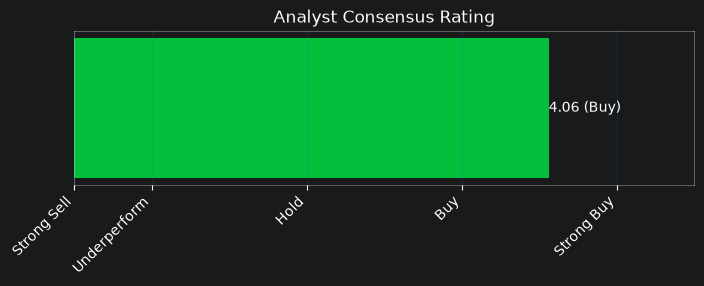

In [16]:
plt.figure(figsize=(8, 2))

plt.barh(["Analyst Rating"], [score], color=color_ratings[analyst_rating])
plt.yticks([])

plt.xlim(1, 5)

plt.text(score, 0, f"{score:.2f} ({analyst_rating})", va="center", ha="left")

plt.xticks([1, 1.5, 2.5, 3.5, 4.5], ["Strong Sell", "Underperform", "Hold", "Buy", "Strong Buy"], rotation=45,
           ha="right")

plt.title("Analyst Consensus Rating")
plt.grid(axis="x", alpha=0.3, color=colors["blue"])

style_spines(alpha=0.3)

plt.show()

In [17]:
upgrades_downgrades = company.get_upgrades_downgrades()
delta = datetime.now() - timedelta(days=365)

upgrades_downgrades = upgrades_downgrades[upgrades_downgrades.index >= delta]

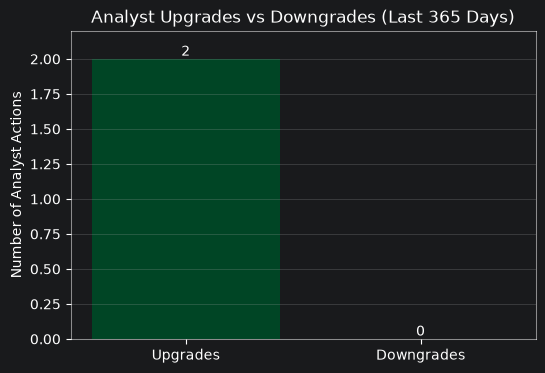

In [18]:
up_down = upgrades_downgrades[upgrades_downgrades["Action"].isin(["up", "down"])]
counts = up_down["Action"].value_counts()

plt.figure(figsize=(6, 4))

bars = plt.bar(
    ["Upgrades", "Downgrades"],
    [counts.get("up", 0), counts.get("down", 0)],
    color=[colors["green"], colors["red"]]
)
plt.bar_label(bars)

plt.ylim(0, counts.max() * 1.1)

plt.ylabel("Number of Analyst Actions")
plt.title("Analyst Upgrades vs Downgrades (Last 365 Days)")

plt.grid(axis="y", alpha=0.3)

style_spines()

plt.show()

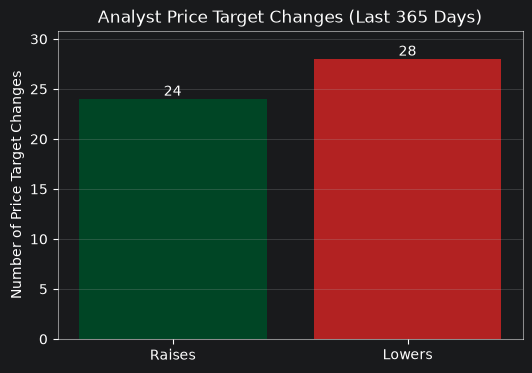

In [19]:
price_targets = upgrades_downgrades[upgrades_downgrades["priceTargetAction"].isin(["Raises", "Lowers"])]
counts = price_targets["priceTargetAction"].value_counts()

plt.figure(figsize=(6, 4))

bars = plt.bar(
    ["Raises", "Lowers"],
    [counts.get("Raises", 0), counts.get("Lowers", 0)],
    color=[colors["green"], colors["red"]]
)
plt.bar_label(bars)

plt.ylim(0, counts.max() * 1.1)

plt.ylabel("Number of Price Target Changes")
plt.title("Analyst Price Target Changes (Last 365 Days)")

plt.grid(axis="y", alpha=0.3)

style_spines()

plt.show()

In [20]:
price_targets["Change %"] = (
        (price_targets["currentPriceTarget"] - price_targets["priorPriceTarget"])
        / price_targets["priorPriceTarget"]
        * 100
)

stats = price_targets.groupby("priceTargetAction")["Change %"].agg(["min", "max", "mean"])

print(f"Average Raise: {stats.loc["Raises", "mean"]:.2f}%")
print(f"Average Lower: {stats.loc["Lowers", "mean"]:.2f}%")
print(f"Average Change: {price_targets["Change %"].mean():.2f}%")
print(f"\nLargest Raise: {stats.loc["Raises", "max"]:.2f}%")
print(f"Largest Lower: {stats.loc["Lowers", "min"]:.2f}%")

Average Raise: 8.74%
Average Lower: -5.78%
Average Change: 0.92%

Largest Raise: 52.44%
Largest Lower: -18.03%
